# OpenSourcePulse — Network Analysis

## Repository–Contributor Collaboration Network

### Objective

Analyze the collaboration structure between GitHub repositories and contributors using the collected contributor dataset.

### Research Questions

1. How is contributor participation distributed across repositories?
2. Which contributors participate across multiple repositories?
3. What structural patterns emerge in the repository–contributor network?
4. Which repositories have highly concentrated or distributed contribution structures?

### Methodology

1. Load repository and contributor datasets.
2. Validate contributor records and repository coverage.
3. Analyze contributor participation distribution.
4. Construct a weighted bipartite repository–contributor network.
5. Analyze repository and contributor degree.
6. Measure network structure and connected components.
7. Construct a contributor–contributor projection where appropriate.
8. Calculate centrality measures.
9. Visualize the collaboration structure.

### Scope

The network represents the observed contributor data for the selected repository sample.
It should not be interpreted as a complete representation of GitHub-wide collaboration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load datasets

repos = pd.read_csv("../data/raw/repositories.csv")
contributors = pd.read_csv("../data/raw/repository_contributors.csv")

print("Repositories shape:", repos.shape)
print("Contributors shape:", contributors.shape)

display(repos.head())
display(contributors.head())

Repositories shape: (300, 20)
Contributors shape: (37656, 5)


,repo_id,repo_name,owner,full_name,description,html_url,language,topics,license,created_at,updated_at,pushed_at,stars,forks,watchers,open_issues,size_kb,default_branch,is_fork,archived
0,196753133,pdf-to-printer,artiebits,artiebits/pdf-to-printer,Print PDFs and images directly to Windows prin...,https://github.com/artiebits/pdf-to-printer,TypeScript,electron|jpeg|nodejs|pdf|pdf-printer|png|print...,MIT,2019-07-13T18:20:35Z,2026-09-13T02:57:38Z,2026-09-10T00:56:01Z,499,148,499,8,34381,master,False,False
1,535160981,nutshell,cashubtc,cashubtc/nutshell,Chaumian ecash wallet and mint for Bitcoin,https://github.com/cashubtc/nutshell,Python,bitcoin|ecash|lightning-network|privacy,MIT,2022-09-11T01:26:19Z,2026-09-17T13:03:23Z,2026-09-17T15:07:21Z,499,179,499,135,27727,main,False,False
2,236093531,SharpStay,0xthirteen,0xthirteen/SharpStay,.NET project for installing Persistence,https://github.com/0xthirteen/SharpStay,C#,NaN,GPL-3.0,2020-01-24T22:22:07Z,2026-09-17T02:53:50Z,2024-06-26T15:54:52Z,499,99,499,3,32,master,False,False
3,24151545,gulp-patterns,johnpapa,johnpapa/gulp-patterns,Playground for Gulp Recipes,https://github.com/johnpapa/gulp-patterns,JavaScript,NaN,NaN,2014-09-17T15:52:39Z,2026-09-01T17:29:00Z,2018-10-31T03:55:37Z,499,136,499,23,33146,master,False,False
4,12715951,TACTIC,Southpaw-TACTIC,Southpaw-TACTIC/TACTIC,Open source remote collaboration platform used...,https://github.com/Southpaw-TACTIC/TACTIC,JavaScript,digital-assets|remote-collaboration|vfx|visual...,NOASSERTION,2013-09-10T00:06:41Z,2026-09-01T14:35:04Z,2026-05-24T01:24:56Z,499,170,499,30,184238,5.0,False,False


,repo_id,full_name,contributor_login,contributor_id,contributions
0,196753133,artiebits/pdf-to-printer,artiebits,29281882,154
1,196753133,artiebits/pdf-to-printer,dependabot[bot],49699333,143
2,196753133,artiebits/pdf-to-printer,dependabot-preview[bot],27856297,110
3,196753133,artiebits/pdf-to-printer,github-actions[bot],41898282,8
4,196753133,artiebits/pdf-to-printer,ferretwithaberet,46427158,6


In [3]:
# Basic contributor dataset inspection

print("Contributor dataset information:")
contributors.info()

print("\nMissing values:")
display(contributors.isna().sum())

print("\nDuplicate rows:", contributors.duplicated().sum())

print(
    "Duplicate repository-contributor pairs:",
    contributors.duplicated(
        subset=["repo_id", "contributor_id"]
    ).sum()
)

Contributor dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 37656 entries, 0 to 37655
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   repo_id            37656 non-null  int64
 1   full_name          37656 non-null  str  
 2   contributor_login  37656 non-null  str  
 3   contributor_id     37656 non-null  int64
 4   contributions      37656 non-null  int64
dtypes: int64(3), str(2)
memory usage: 2.5 MB

Missing values:


repo_id              0
full_name            0
contributor_login    0
contributor_id       0
contributions        0
dtype: int64


Duplicate rows: 0
Duplicate repository-contributor pairs: 0


## 1. Contributor Data Coverage

Before constructing the network, repository coverage is validated.

This is important because some GitHub repositories may not return complete contributor
information through the API. API-unavailable repositories must not be interpreted as
repositories with zero contributors.

In [4]:
# Repository coverage

repo_ids = set(repos["repo_id"])
contributor_repo_ids = set(contributors["repo_id"])

represented_repos = len(contributor_repo_ids & repo_ids)
missing_from_contributor_dataset = len(repo_ids - contributor_repo_ids)

print("Total sampled repositories:", len(repo_ids))
print("Repositories represented in contributor data:", represented_repos)
print(
    "Repositories without contributor records:",
    missing_from_contributor_dataset
)

missing_repo_ids = repo_ids - contributor_repo_ids

if missing_repo_ids:
    missing_repos = repos[
        repos["repo_id"].isin(missing_repo_ids)
    ][["repo_id", "full_name", "stars", "language"]]

    print("\nRepositories without contributor records:")
    display(missing_repos)

Total sampled repositories: 300
Repositories represented in contributor data: 297
Repositories without contributor records: 3

Repositories without contributor records:


,repo_id,full_name,stars,language
191,120360765,chromium/chromium,24799,NaN
275,2325298,torvalds/linux,249330,C
284,110198232,MalwareTech/TrickBot-Toolkit,200,Python


In [5]:
# Contributors per repository

contributors_per_repo = (
    contributors
    .groupby("repo_id")["contributor_id"]
    .nunique()
    .reset_index(name="contributors_count")
)

contributors_per_repo = contributors_per_repo.merge(
    repos[["repo_id", "full_name", "stars", "language"]],
    on="repo_id",
    how="left"
)

print("Contributor count summary:")
display(
    contributors_per_repo["contributors_count"]
    .describe()
)

print("\nTop 20 repositories by contributor count:")
display(
    contributors_per_repo
    .sort_values("contributors_count", ascending=False)
    .head(20)
)

Contributor count summary:


count    297.000000
mean     126.787879
std      151.138021
min        1.000000
25%       12.000000
50%       50.000000
75%      194.000000
max      474.000000
Name: contributors_count, dtype: float64


Top 20 repositories by contributor count:


,repo_id,contributors_count,full_name,stars,language
249,666299222,474,openinterpreter/openinterpreter,68364,Rust
143,85077558,468,nilbuild/developer-roadmap,367527,TypeScript
238,552661142,467,langchain-ai/langchain,146532,Python
176,162613268,466,ethereum-lists/chains,9828,Kotlin
229,455229168,461,immich-app/immich,114568,TypeScript
258,771302083,460,OpenHands/OpenHands,88307,TypeScript
53,15634981,459,godotengine/godot,117364,C++
271,975734319,456,anomalyco/opencode,208133,TypeScript
126,63476337,450,TheAlgorithms/Python,224678,Python
233,488641606,442,agno-agi/agno,42218,Python


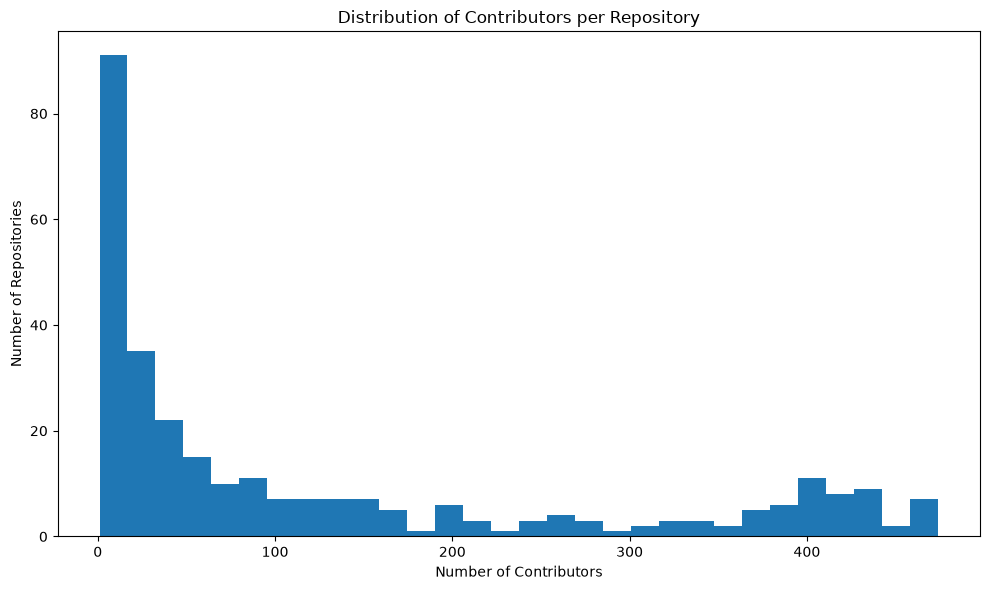

In [6]:
# Distribution of contributors per repository

plt.figure(figsize=(10, 6))

plt.hist(
    contributors_per_repo["contributors_count"],
    bins=30
)

plt.xlabel("Number of Contributors")
plt.ylabel("Number of Repositories")
plt.title("Distribution of Contributors per Repository")

plt.tight_layout()
plt.show()

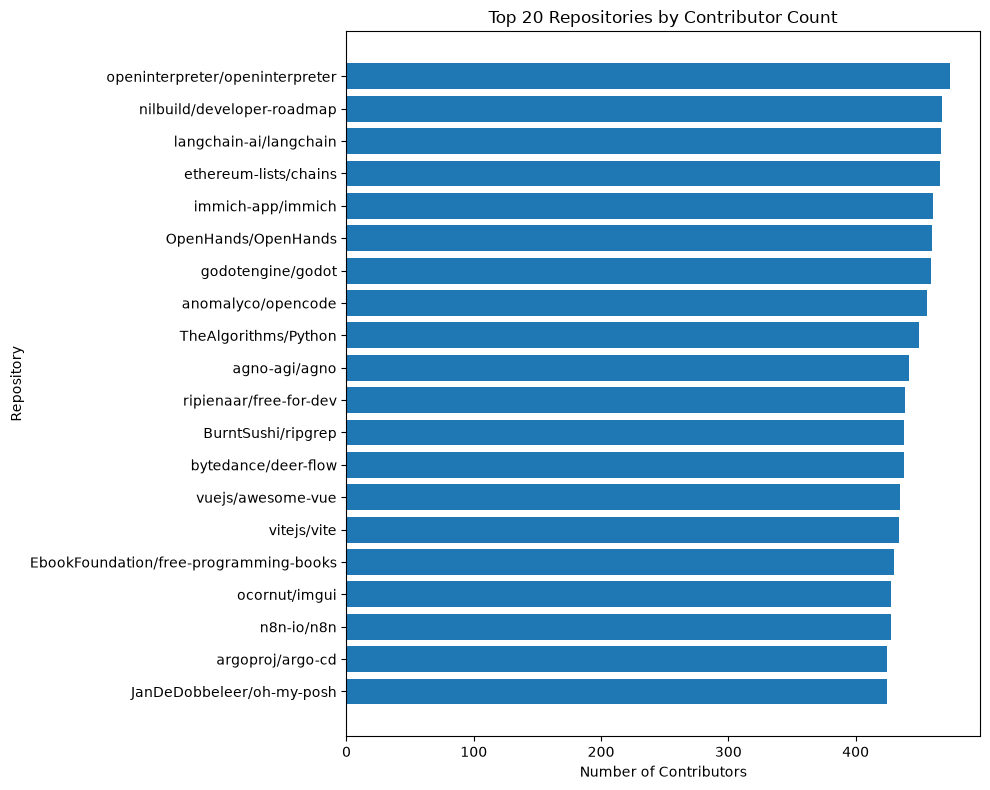

In [7]:
# Top 20 contributor-rich repositories

top_repos = (
    contributors_per_repo
    .sort_values("contributors_count", ascending=False)
    .head(20)
    .sort_values("contributors_count")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_repos["full_name"],
    top_repos["contributors_count"]
)

plt.xlabel("Number of Contributors")
plt.ylabel("Repository")
plt.title("Top 20 Repositories by Contributor Count")

plt.tight_layout()
plt.show()

In [8]:
# Contributor participation across repositories

repos_per_contributor = (
    contributors
    .groupby("contributor_id")["repo_id"]
    .nunique()
    .reset_index(name="repository_count")
)

print("Repository participation per contributor:")
display(
    repos_per_contributor["repository_count"]
    .describe()
)

print("\nTop cross-repository contributors:")
display(
    repos_per_contributor
    .sort_values("repository_count", ascending=False)
    .head(20)
)

Repository participation per contributor:


count    35142.000000
mean         1.071538
std          0.781355
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        115.000000
Name: repository_count, dtype: float64


Top cross-repository contributors:


,contributor_id,repository_count
26544,49699333,115
20891,22633385,42
25056,41898282,41
34010,198982749,31
22054,26602940,16
15218,8518239,14
22223,27856297,10
22460,29139614,10
10719,3691490,10
3822,455140,10


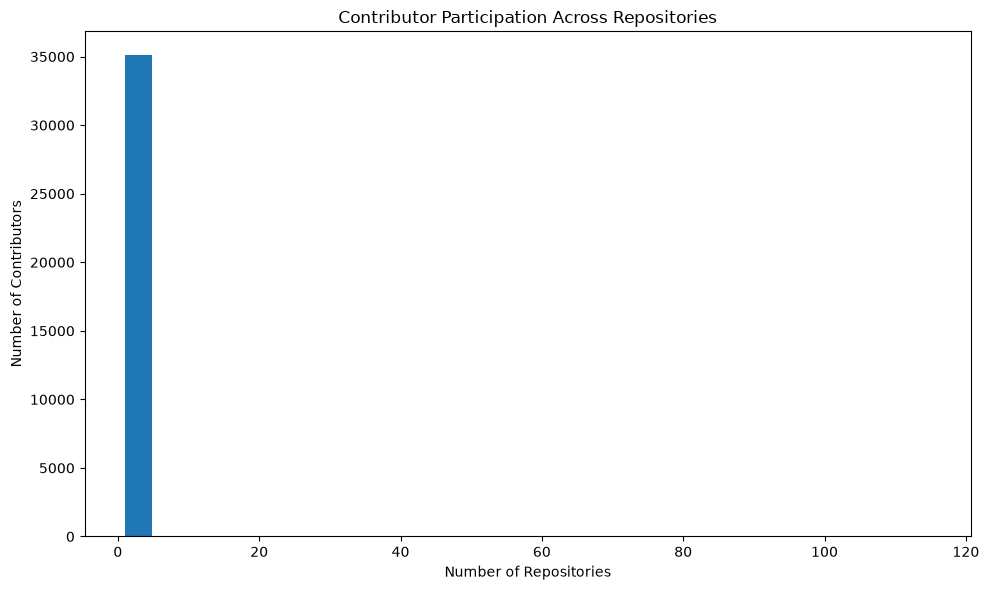

In [9]:
# Distribution of contributor participation

plt.figure(figsize=(10, 6))

plt.hist(
    repos_per_contributor["repository_count"],
    bins=30
)

plt.xlabel("Number of Repositories")
plt.ylabel("Number of Contributors")
plt.title("Contributor Participation Across Repositories")

plt.tight_layout()
plt.show()

## 2. Repository–Contributor Bipartite Network

A bipartite network contains two different node types:

- Repository nodes
- Contributor nodes

An edge represents a contributor relationship with a repository.

The edge weight represents the number of contributions made by that contributor
to that repository.

This representation preserves the actual repository–contributor relationship
without artificially connecting repositories or contributors that do not have
an observed relationship.

In [10]:
# Build weighted bipartite repository-contributor network

B = nx.Graph()

# Add repository nodes
for _, row in repos.iterrows():
    B.add_node(
        f"repo_{row['repo_id']}",
        node_type="repository",
        repo_id=row["repo_id"],
        label=row["full_name"]
    )

# Add contributor nodes and weighted edges
for _, row in contributors.iterrows():

    contributor_node = f"contributor_{row['contributor_id']}"

    B.add_node(
        contributor_node,
        node_type="contributor",
        contributor_id=row["contributor_id"],
        label=row["contributor_login"]
    )

    B.add_edge(
        f"repo_{row['repo_id']}",
        contributor_node,
        weight=row["contributions"]
    )

print("Network successfully constructed.")
print("Total nodes:", B.number_of_nodes())
print("Total edges:", B.number_of_edges())

Network successfully constructed.
Total nodes: 35442
Total edges: 37656


In [11]:
# Network composition

repository_nodes = [
    n for n, d in B.nodes(data=True)
    if d["node_type"] == "repository"
]

contributor_nodes = [
    n for n, d in B.nodes(data=True)
    if d["node_type"] == "contributor"
]

print("Repository nodes:", len(repository_nodes))
print("Contributor nodes:", len(contributor_nodes))
print("Total nodes:", B.number_of_nodes())
print("Total edges:", B.number_of_edges())

print(
    "\nRepository-to-contributor node ratio:",
    round(
        len(contributor_nodes) / len(repository_nodes), 2
    )
)

Repository nodes: 300
Contributor nodes: 35142
Total nodes: 35442
Total edges: 37656

Repository-to-contributor node ratio: 117.14


In [12]:
# Network density

density = nx.density(B)

print(f"Network density: {density:.8f}")

Network density: 0.00005996


In [13]:
# Connected components

components = list(nx.connected_components(B))

component_sizes = sorted(
    [len(component) for component in components],
    reverse=True
)

print("Number of connected components:", len(component_sizes))

print("\nLargest component sizes:")
print(component_sizes[:10])

largest_component = max(
    nx.connected_components(B),
    key=len
)

print(
    "\nLargest connected component:",
    len(largest_component),
    "nodes"
)

print(
    "Percentage of network in largest component:",
    round(
        len(largest_component) / B.number_of_nodes() * 100,
        2
    ),
    "%"
)

Number of connected components: 59

Largest component sizes:
[34965, 69, 25, 25, 21, 20, 18, 18, 17, 17]

Largest connected component: 34965 nodes
Percentage of network in largest component: 98.65 %


In [14]:
# Repository degree analysis

repo_degree = []

for node in repository_nodes:

    repo_degree.append({
        "repo_node": node,
        "repo_id": B.nodes[node]["repo_id"],
        "full_name": B.nodes[node]["label"],
        "degree": B.degree(node)
    })

repo_degree = pd.DataFrame(repo_degree)

repo_degree = repo_degree.merge(
    repos[["repo_id", "stars", "language"]],
    on="repo_id",
    how="left"
)

print("Top repositories by network degree:")
display(
    repo_degree
    .sort_values("degree", ascending=False)
    .head(20)
)

Top repositories by network degree:


,repo_node,repo_id,full_name,degree,stars,language
224,repo_666299222,666299222,openinterpreter/openinterpreter,474,68364,Rust
276,repo_85077558,85077558,nilbuild/developer-roadmap,468,367527,TypeScript
251,repo_552661142,552661142,langchain-ai/langchain,467,146532,Python
138,repo_162613268,162613268,ethereum-lists/chains,466,9828,Kotlin
253,repo_455229168,455229168,immich-app/immich,461,114568,TypeScript
240,repo_771302083,771302083,OpenHands/OpenHands,460,88307,TypeScript
258,repo_15634981,15634981,godotengine/godot,459,117364,C++
267,repo_975734319,975734319,anomalyco/opencode,456,208133,TypeScript
269,repo_63476337,63476337,TheAlgorithms/Python,450,224678,Python
199,repo_488641606,488641606,agno-agi/agno,442,42218,Python


In [15]:
# Contributor degree analysis

contributor_degree = []

for node in contributor_nodes:

    contributor_degree.append({
        "contributor_node": node,
        "contributor_id": B.nodes[node]["contributor_id"],
        "login": B.nodes[node]["label"],
        "degree": B.degree(node)
    })

contributor_degree = pd.DataFrame(contributor_degree)

print("Top contributors by repository degree:")
display(
    contributor_degree
    .sort_values("degree", ascending=False)
    .head(20)
)

Top contributors by repository degree:


,contributor_node,contributor_id,login,degree
1,contributor_49699333,49699333,dependabot[bot],115
2545,contributor_22633385,22633385,eltociear,42
3,contributor_41898282,41898282,github-actions[bot],41
559,contributor_198982749,198982749,Copilot,31
4349,contributor_26602940,26602940,0xflotus,16
221,contributor_8518239,8518239,gitter-badger,14
3919,contributor_29139614,29139614,renovate[bot],10
2,contributor_27856297,27856297,dependabot-preview[bot],10
6347,contributor_455140,455140,mvanhorn,10
2500,contributor_3691490,3691490,PeterDaveHello,10


In [16]:
# Weighted repository contribution strength

repo_strength = []

for node in repository_nodes:

    strength = sum(
        data["weight"]
        for _, _, data in B.edges(node, data=True)
    )

    repo_strength.append({
        "repo_node": node,
        "repo_id": B.nodes[node]["repo_id"],
        "full_name": B.nodes[node]["label"],
        "contribution_strength": strength
    })

repo_strength = pd.DataFrame(repo_strength)

print("Top repositories by total contribution strength:")

display(
    repo_strength
    .sort_values(
        "contribution_strength",
        ascending=False
    )
    .head(20)
)

Top repositories by total contribution strength:


,repo_node,repo_id,full_name,contribution_strength
248,repo_41881900,41881900,microsoft/vscode,140969
271,repo_1103012935,1103012935,openclaw/openclaw,90915
258,repo_15634981,15634981,godotengine/godot,79514
216,repo_1644196,1644196,JuliaLang/julia,55455
193,repo_30203935,30203935,metabase/metabase,42226
134,repo_18719856,18719856,Stellarium/stellarium,37045
209,repo_40276274,40276274,ziglang/zig,34287
270,repo_1024554267,1024554267,NousResearch/hermes-agent,32035
208,repo_17728164,17728164,hashicorp/terraform,30793
272,repo_28457823,28457823,freeCodeCamp/freeCodeCamp,25024


In [17]:
# Compare repository degree with total contribution strength

repo_network_summary = (
    repo_degree[
        ["repo_id", "full_name", "degree", "stars", "language"]
    ]
    .merge(
        repo_strength[
            ["repo_id", "contribution_strength"]
        ],
        on="repo_id",
        how="left"
    )
)

display(
    repo_network_summary
    .sort_values("degree", ascending=False)
    .head(20)
)

,repo_id,full_name,degree,stars,language,contribution_strength
224,666299222,openinterpreter/openinterpreter,474,68364,Rust,10610
276,85077558,nilbuild/developer-roadmap,468,367527,TypeScript,6512
251,552661142,langchain-ai/langchain,467,146532,Python,11724
138,162613268,ethereum-lists/chains,466,9828,Kotlin,2301
253,455229168,immich-app/immich,461,114568,TypeScript,10431
240,771302083,OpenHands/OpenHands,460,88307,TypeScript,7851
258,15634981,godotengine/godot,459,117364,C++,79514
267,975734319,anomalyco/opencode,456,208133,TypeScript,14156
269,63476337,TheAlgorithms/Python,450,224678,Python,2850
199,488641606,agno-agi/agno,442,42218,Python,5946


In [18]:
# Save network analysis outputs

repo_network_summary.to_csv(
    "../reports/repository_network_summary.csv",
    index=False
)

contributor_degree.to_csv(
    "../reports/contributor_network_degree.csv",
    index=False
)

contributors_per_repo.to_csv(
    "../reports/contributors_per_repository.csv",
    index=False
)

repos_per_contributor.to_csv(
    "../reports/repositories_per_contributor.csv",
    index=False
)

print("Network analysis summary files saved successfully.")

Network analysis summary files saved successfully.


## 3. Contributor–Contributor Collaboration Network

The bipartite network represents direct repository–contributor relationships.

To study collaboration between contributors, a one-mode projection is constructed.

Two contributors are connected when they have contributed to the same repository.

The edge weight represents the number of repositories shared by the two contributors.

This projection provides a complementary view of the collaboration structure.

In [20]:
# Identify bot/service accounts explicitly

contributors["is_bot_or_service"] = (
    contributors["contributor_login"]
    .astype(str)
    .str.lower()
    .str.contains(
        r"\[bot\]|dependabot|github-actions|renovate",
        regex=True,
        na=False
    )
)

print("Total contributor records:", len(contributors))
print(
    "Bot/service contributor records:",
    contributors["is_bot_or_service"].sum()
)

print(
    "Non-bot contributor records:",
    (~contributors["is_bot_or_service"]).sum()
)

print("\nBot/service accounts observed:")
display(
    contributors.loc[
        contributors["is_bot_or_service"],
        "contributor_login"
    ].value_counts().head(20)
)

Total contributor records: 37656
Bot/service contributor records: 245
Non-bot contributor records: 37411

Bot/service accounts observed:


contributor_login
dependabot[bot]                         115
github-actions[bot]                      41
dependabot-preview[bot]                  10
renovate[bot]                            10
pre-commit-ci[bot]                        6
greenkeeper[bot]                          4
allcontributors[bot]                      3
renovate-bot                              3
devin-ai-integration[bot]                 3
google-labs-jules[bot]                    2
autofix-ci[bot]                           2
open-swe[bot]                             2
claude[bot]                               2
blacksmith-sh[bot]                        2
imgbot[bot]                               1
hf-dependantbot-rollout[bot]              1
transifex-integration[bot]                1
smithery[bot]                             1
gitlocalize-app[bot]                      1
microsoft-github-policy-service[bot]      1
Name: count, dtype: int64

In [21]:
# Build human-oriented contributor membership table

human_contributors = contributors[
    ~contributors["is_bot_or_service"]
].copy()

human_memberships = (
    human_contributors[
        ["contributor_id", "contributor_login", "repo_id"]
    ]
    .drop_duplicates()
)

print(
    "Unique human-oriented contributor-repository relationships:",
    len(human_memberships)
)

print(
    "Unique human-oriented contributors:",
    human_memberships["contributor_id"].nunique()
)

print(
    "Unique repositories represented:",
    human_memberships["repo_id"].nunique()
)

Unique human-oriented contributor-repository relationships: 37411
Unique human-oriented contributors: 35088
Unique repositories represented: 297


In [22]:
# Cross-repository contributor participation

human_repo_counts = (
    human_memberships
    .groupby(
        ["contributor_id", "contributor_login"]
    )["repo_id"]
    .nunique()
    .reset_index(name="repository_count")
)

print("Human-oriented contributor participation:")
display(
    human_repo_counts
    .sort_values("repository_count", ascending=False)
    .head(20)
)

Human-oriented contributor participation:


,contributor_id,contributor_login,repository_count
20891,22633385,eltociear,42
33975,198982749,Copilot,31
22051,26602940,0xflotus,16
15218,8518239,gitter-badger,14
10719,3691490,PeterDaveHello,10
3822,455140,mvanhorn,10
1226,81847,claude,9
18564,15367484,ReadmeCritic,8
28641,65916846,actions-user,8
15169,8433587,spekulatius,8


In [23]:
# Contributors participating in multiple repositories

multi_repo_contributors = human_repo_counts[
    human_repo_counts["repository_count"] >= 2
].copy()

print(
    "Contributors participating in 2+ repositories:",
    len(multi_repo_contributors)
)

print(
    "Percentage of human-oriented contributors participating in 2+ repositories:",
    round(
        len(multi_repo_contributors)
        / len(human_repo_counts)
        * 100,
        2
    ),
    "%"
)

Contributors participating in 2+ repositories: 1781
Percentage of human-oriented contributors participating in 2+ repositories: 5.08 %


In [24]:
# Build contributor-contributor projection efficiently

from itertools import combinations
from collections import defaultdict

repo_to_contributors = defaultdict(list)

for repo_id, group in human_memberships.groupby("repo_id"):
    repo_to_contributors[repo_id] = (
        group["contributor_id"]
        .drop_duplicates()
        .tolist()
    )

projection_weights = defaultdict(int)

for repo_id, contributor_list in repo_to_contributors.items():

    if len(contributor_list) < 2:
        continue

    for c1, c2 in combinations(
        sorted(contributor_list), 2
    ):
        projection_weights[(c1, c2)] += 1

print(
    "Contributor pairs with at least one shared repository:",
    len(projection_weights)
)

Contributor pairs with at least one shared repository: 5671088


In [25]:
# Construct contributor-contributor graph

C = nx.Graph()

# Add contributor nodes
for _, row in human_repo_counts.iterrows():

    C.add_node(
        int(row["contributor_id"]),
        login=row["contributor_login"],
        repository_count=int(row["repository_count"])
    )

# Add weighted collaboration edges
for (c1, c2), shared_repositories in projection_weights.items():

    C.add_edge(
        c1,
        c2,
        weight=shared_repositories
    )

print("Contributor projection constructed.")
print("Nodes:", C.number_of_nodes())
print("Edges:", C.number_of_edges())

Contributor projection constructed.
Nodes: 35088
Edges: 5671088


In [26]:
# Contributor projection statistics

print("Number of contributors:", C.number_of_nodes())
print("Number of collaboration edges:", C.number_of_edges())

if C.number_of_nodes() > 1:
    print(
        "Network density:",
        round(nx.density(C), 6)
    )

components_C = list(nx.connected_components(C))

component_sizes_C = sorted(
    [len(c) for c in components_C],
    reverse=True
)

print(
    "Connected components:",
    len(component_sizes_C)
)

print(
    "Largest component size:",
    component_sizes_C[0]
)

print(
    "Largest component percentage:",
    round(
        component_sizes_C[0]
        / C.number_of_nodes()
        * 100,
        2
    ),
    "%"
)

Number of contributors: 35088
Number of collaboration edges: 5671088
Network density: 0.009213
Connected components: 64
Largest component size: 34529
Largest component percentage: 98.41 %


In [27]:
# Contributor collaboration degree

collaboration_degree = pd.DataFrame({
    "contributor_id": list(C.nodes()),
    "collaboration_degree": [
        C.degree(node)
        for node in C.nodes()
    ]
})

collaboration_degree["login"] = (
    collaboration_degree["contributor_id"]
    .map(
        human_repo_counts
        .set_index("contributor_id")["contributor_login"]
    )
)

collaboration_degree = (
    collaboration_degree
    .sort_values(
        "collaboration_degree",
        ascending=False
    )
)

print("Top contributors by collaboration degree:")
display(
    collaboration_degree.head(20)
)

Top contributors by collaboration degree:


,contributor_id,collaboration_degree,login
20891,22633385,11833,eltociear
33975,198982749,8281,Copilot
22051,26602940,4359,0xflotus
34777,266937838,2413,octo-patch
28641,65916846,2378,actions-user
18095,14027534,2244,pgoslatara
20021,19658300,2222,majiayu000
3822,455140,2196,mvanhorn
15169,8433587,2148,spekulatius
8986,2119212,2078,jsoref


In [28]:
# Weighted collaboration strength

collaboration_strength = pd.DataFrame({
    "contributor_id": list(C.nodes()),
    "collaboration_strength": [
        sum(
            data["weight"]
            for _, _, data in C.edges(node, data=True)
        )
        for node in C.nodes()
    ]
})

collaboration_strength["login"] = (
    collaboration_strength["contributor_id"]
    .map(
        human_repo_counts
        .set_index("contributor_id")["contributor_login"]
    )
)

collaboration_strength = (
    collaboration_strength
    .sort_values(
        "collaboration_strength",
        ascending=False
    )
)

print("Top contributors by weighted collaboration strength:")
display(
    collaboration_strength.head(20)
)

Top contributors by weighted collaboration strength:


,contributor_id,collaboration_strength,login
20891,22633385,12125,eltociear
33975,198982749,8448,Copilot
22051,26602940,4540,0xflotus
34777,266937838,2473,octo-patch
28641,65916846,2394,actions-user
3822,455140,2270,mvanhorn
20021,19658300,2247,majiayu000
18095,14027534,2247,pgoslatara
15169,8433587,2173,spekulatius
8986,2119212,2089,jsoref


## 4. Centrality Analysis

Degree identifies contributors with many collaboration connections.

Betweenness centrality identifies contributors that frequently lie on shortest
paths between other contributors and may therefore occupy structurally important
positions in the collaboration network.

Because the complete contributor projection may be large, centrality analysis
is performed on the largest connected component.

In [29]:
# Largest connected component for centrality analysis

largest_C_nodes = max(
    nx.connected_components(C),
    key=len
)

C_largest = C.subgraph(
    largest_C_nodes
).copy()

print(
    "Largest contributor component nodes:",
    C_largest.number_of_nodes()
)

print(
    "Largest contributor component edges:",
    C_largest.number_of_edges()
)

Largest contributor component nodes: 34529
Largest contributor component edges: 5663732


In [30]:
# Degree centrality

degree_centrality = nx.degree_centrality(
    C_largest
)

degree_centrality_df = pd.DataFrame({
    "contributor_id": list(degree_centrality.keys()),
    "degree_centrality": list(
        degree_centrality.values()
    )
})

degree_centrality_df["login"] = (
    degree_centrality_df["contributor_id"]
    .map(
        human_repo_counts
        .set_index("contributor_id")["contributor_login"]
    )
)

display(
    degree_centrality_df
    .sort_values(
        "degree_centrality",
        ascending=False
    )
    .head(20)
)

,contributor_id,degree_centrality,login
20604,22633385,0.342707,eltociear
33450,198982749,0.239834,Copilot
21753,26602940,0.126245,0xflotus
34222,266937838,0.069885,octo-patch
28241,65916846,0.068872,actions-user
17844,14027534,0.064991,pgoslatara
19748,19658300,0.064354,majiayu000
3778,455140,0.063601,mvanhorn
14969,8433587,0.062210,spekulatius
8866,2119212,0.060183,jsoref


In [31]:
# Betweenness centrality

if C_largest.number_of_nodes() <= 2000:

    betweenness = nx.betweenness_centrality(
        C_largest,
        normalized=True
    )

else:

    sample_size = min(
        500,
        C_largest.number_of_nodes()
    )

    betweenness = nx.betweenness_centrality(
        C_largest,
        k=sample_size,
        normalized=True,
        seed=42
    )

betweenness_df = pd.DataFrame({
    "contributor_id": list(betweenness.keys()),
    "betweenness_centrality": list(
        betweenness.values()
    )
})

betweenness_df["login"] = (
    betweenness_df["contributor_id"]
    .map(
        human_repo_counts
        .set_index("contributor_id")["contributor_login"]
    )
)

print("Top contributors by betweenness centrality:")

display(
    betweenness_df
    .sort_values(
        "betweenness_centrality",
        ascending=False
    )
    .head(20)
)

Top contributors by betweenness centrality:


,contributor_id,betweenness_centrality,login
20604,22633385,0.237377,eltociear
33450,198982749,0.116926,Copilot
21753,26602940,0.041024,0xflotus
17844,14027534,0.015113,pgoslatara
20939,23558090,0.013580,m1guelpf
8866,2119212,0.013126,jsoref
28241,65916846,0.011850,actions-user
15017,8518239,0.010815,gitter-badger
10582,3691490,0.010189,PeterDaveHello
10756,3837473,0.010137,Enochen


## 5. Collaboration Network Visualization

A full 35,000-node graph would be visually unreadable.

Therefore, visualization focuses on the largest connected component and the
most structurally important contributors.

This preserves interpretability while retaining the underlying network analysis.

In [32]:
# Select top contributors for interpretable visualization

top_visual_nodes = (
    degree_centrality_df
    .sort_values(
        "degree_centrality",
        ascending=False
    )
    .head(40)["contributor_id"]
    .tolist()
)

C_visual = C_largest.subgraph(
    top_visual_nodes
).copy()

print(
    "Visualization nodes:",
    C_visual.number_of_nodes()
)

print(
    "Visualization edges:",
    C_visual.number_of_edges()
)

Visualization nodes: 40
Visualization edges: 267


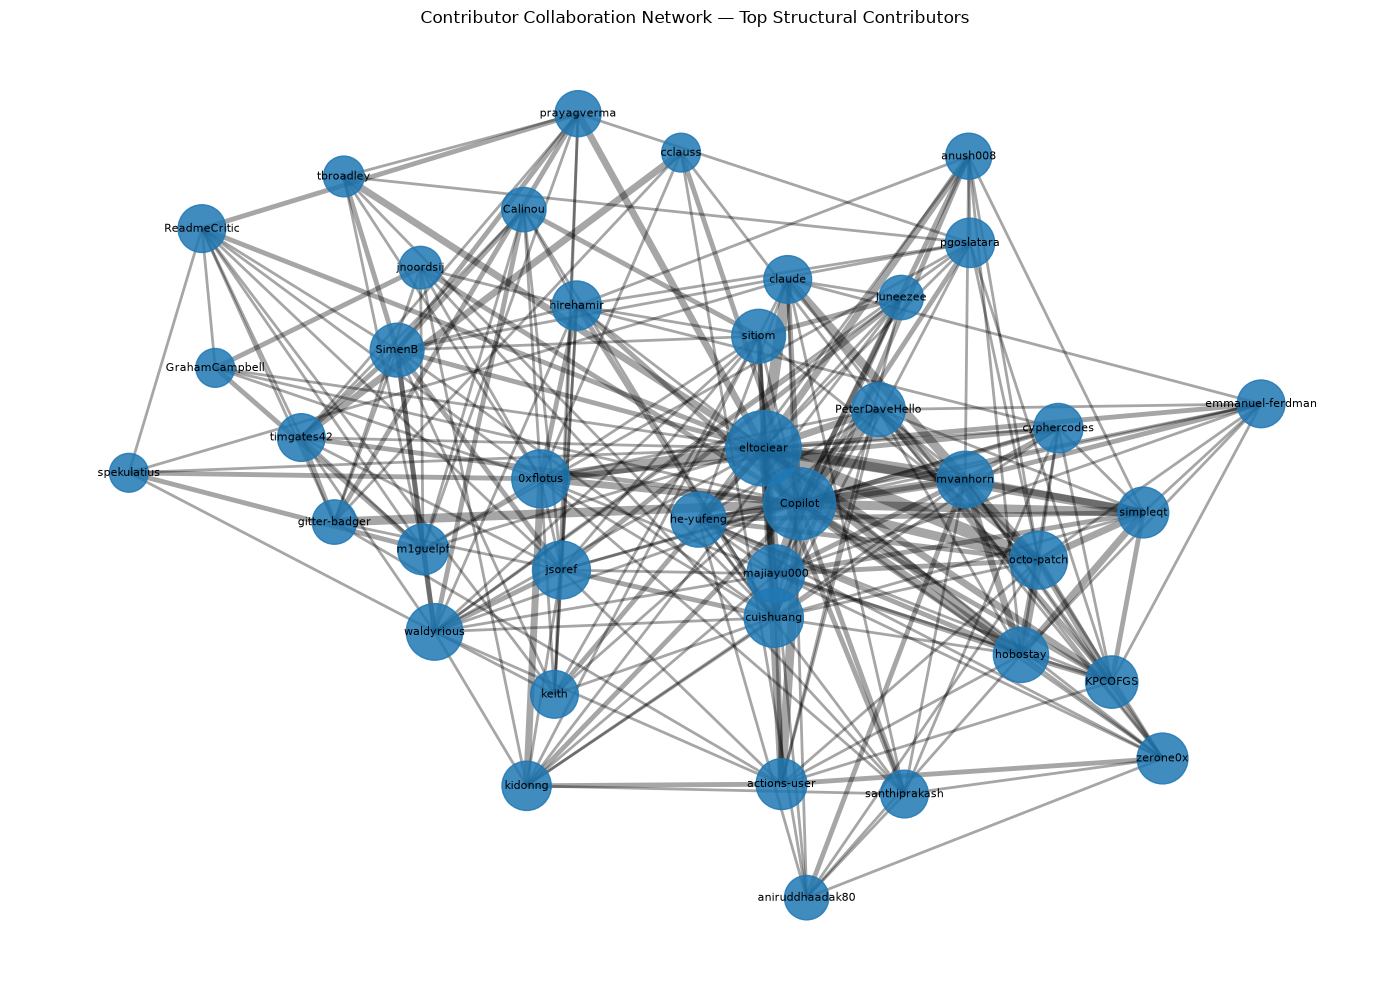

In [33]:
# Collaboration network visualization

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    C_visual,
    seed=42,
    k=1.5
)

node_sizes = [
    300 + 80 * C_visual.degree(node)
    for node in C_visual.nodes()
]

edge_widths = [
    0.5 + 1.5 * data["weight"]
    for _, _, data in C_visual.edges(data=True)
]

nx.draw_networkx_nodes(
    C_visual,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_edges(
    C_visual,
    pos,
    width=edge_widths,
    alpha=0.35
)

labels = {
    node: C_visual.nodes[node]["login"]
    for node in C_visual.nodes()
}

nx.draw_networkx_labels(
    C_visual,
    pos,
    labels=labels,
    font_size=8
)

plt.title(
    "Contributor Collaboration Network — Top Structural Contributors"
)

plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Network Findings

The network analysis provides several complementary views of repository collaboration:

### Repository-level collaboration
Repository degree measures the breadth of contributor participation.

### Contribution strength
Weighted contribution strength captures contribution volume and complements
simple contributor counts.

### Cross-repository participation
Contributor participation across multiple repositories identifies contributors
who connect otherwise separate repository communities.

### Contributor projection
The contributor–contributor network represents collaboration through shared
repository participation.

### Centrality
Degree centrality identifies highly connected contributors, while betweenness
centrality highlights structurally important bridging contributors.

### Limitation

The contributor dataset is based on GitHub API results for the selected sample.
Large repositories may have API limitations, and contributor records may include
bot or service accounts. Therefore, the network represents observed collaboration
rather than the complete GitHub collaboration ecosystem.

In [34]:
# Save network outputs

repo_network_summary.to_csv(
    "../reports/repository_network_summary.csv",
    index=False
)

contributor_degree.to_csv(
    "../reports/contributor_network_degree.csv",
    index=False
)

contributors_per_repo.to_csv(
    "../reports/contributors_per_repository.csv",
    index=False
)

repos_per_contributor.to_csv(
    "../reports/repositories_per_contributor.csv",
    index=False
)

human_repo_counts.to_csv(
    "../reports/human_contributor_repository_counts.csv",
    index=False
)

collaboration_degree.to_csv(
    "../reports/contributor_collaboration_degree.csv",
    index=False
)

collaboration_strength.to_csv(
    "../reports/contributor_collaboration_strength.csv",
    index=False
)

degree_centrality_df.to_csv(
    "../reports/contributor_degree_centrality.csv",
    index=False
)

betweenness_df.to_csv(
    "../reports/contributor_betweenness_centrality.csv",
    index=False
)

print("All network analysis outputs saved successfully.")

All network analysis outputs saved successfully.


## Key Network Findings

1. The contributor dataset contains 37,656 observed repository–contributor relationships across 300 sampled repositories.

2. 297 of the 300 sampled repositories were represented in the contributor dataset. The three missing cases correspond to previously identified API limitations or a valid zero-contributor response.

3. The repository–contributor bipartite network contains 300 repository nodes and 35,142 contributor nodes.

4. Human-oriented filtering identified 35,088 contributors, of whom 1,781 (5.08%) participated across two or more sampled repositories.

5. The contributor–contributor projection contains 35,088 nodes and 5,671,088 collaboration edges.

6. Although the projected network is sparse (density ≈ 0.0092), 98.41% of contributors belong to one largest connected component, indicating broad structural connectivity through indirect collaboration paths.

7. Collaboration degree identifies highly connected contributors, while weighted collaboration strength captures the intensity of their shared repository relationships.

8. Betweenness centrality identifies contributors occupying structurally important bridging positions. These measures represent network structure and should not be interpreted as measures of developer quality or importance.

9. Bot and service accounts were explicitly identified and excluded from the human-oriented projection to reduce distortion from automated contribution systems.

10. The network represents observed GitHub API data for the selected analytical sample and therefore does not constitute a complete representation of GitHub-wide collaboration.